Завантаження данних

In [1]:
import pandas as pd

data = pd.read_csv("Student_Performance.csv")  # вкажіть правильний шлях до файлу
data.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


Попередня обробка даних

In [4]:
import pandas as pd

# Перевірка наявності пропущених значень
missing_values = data.isnull().sum()
print(missing_values[missing_values > 0])

# Заповнення пропущених значень середнім (для числових) або модою (для текстових/категоріальних)
for column in data.columns:
    if pd.api.types.is_numeric_dtype(data[column]):
        data[column] = data[column].fillna(data[column].mean())
    else:
        data[column] = data[column].fillna(data[column].mode()[0])

# Перевірка реальних назв колонок
print(data.columns.tolist())

# Базовий аналіз кореляцій (тільки числові колонки)
correlation = data.corr(numeric_only=True)
print(correlation.iloc[:, -1].sort_values(ascending=False).head(10))

Series([], dtype: int64)
['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index']
Performance Index                   1.000000
Previous Scores                     0.915189
Hours Studied                       0.373730
Sleep Hours                         0.048106
Sample Question Papers Practiced    0.043268
Name: Performance Index, dtype: float64


Розподіл данних

In [8]:
from sklearn.model_selection import train_test_split

# Вибір залежної змінної та характеристик
target_column = "Performance Index"

X = data.drop(target_column, axis=1).select_dtypes(include=["number"])  # тільки числові дані
y = data[target_column]

# Розподіл на тренувальний і тестовий набори
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8000, 4)
X_test shape: (2000, 4)
y_train shape: (8000,)
y_test shape: (2000,)


Побудова моделі лінійної регресії

In [9]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[2.85,1.02,0.47,0.19]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Hours Studied','Previous Scores','Sleep Hours', 'Sample Question Papers Practiced']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-33.6
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


Оцінка моделі

R^2: 0.9887144552384186
MSE: 4.182254914593818


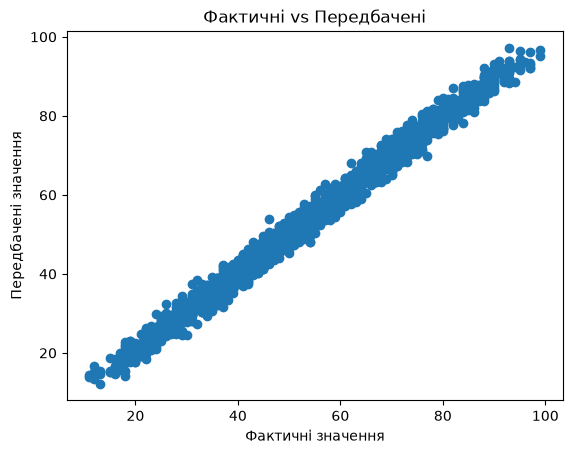

In [10]:
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f"R^2: {r2}")
print(f"MSE: {mse}")

plt.scatter(y_test, y_pred)
plt.xlabel("Фактичні значення")
plt.ylabel("Передбачені значення")
plt.title("Фактичні vs Передбачені")
plt.show()

Додаткове завдання: інші алгоритми регресії

In [11]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor

# Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)
print(f"Ridge R^2: {r2_score(y_test, ridge_pred)}")

# Lasso Regression
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_test)
print(f"Lasso R^2: {r2_score(y_test, lasso_pred)}")

# Decision Tree Regressor
tree_model = DecisionTreeRegressor(max_depth=5)
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)
print(f"Decision Tree R^2: {r2_score(y_test, tree_pred)}")

Ridge R^2: 0.9887144377403252
Lasso R^2: 0.9886744148798808
Decision Tree R^2: 0.9649552902097726
